# Clustering y selección de modelo

Comparamos varios algoritmos y K distintos. La decisión final no se toma por una sola métrica sino por el balance entre métricas internas, estabilidad y accionabilidad de negocio.

**Autor:** Andrés Fernando Gómez Rojas

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from src.clustering import (select_k, fit_final_model, benchmark_algorithms,
                             validate_stability, validate_holdout, CLUSTER_NAMES)

X = np.load('../models/X.npy')
df = pd.read_pickle('../data/processed/df_processed.pkl')
print(f'X shape: {X.shape}')

X shape: (9996, 32)


## Selección de K

Evaluamos KMeans para K entre 2 y 8 con cuatro métricas internas. Cada métrica capta un aspecto diferente:

* **Silhouette:** mide qué tan cerca está cada punto de su cluster vs del cluster vecino más cercano. Valores entre 0 y 1, mayor es mejor.
* **Calinski-Harabasz:** ratio de dispersión entre clusters vs dentro de clusters. Mayor es mejor.
* **Davies-Bouldin:** similitud promedio entre cada cluster y el más parecido. Menor es mejor.
* **Inertia:** suma de distancias al centroide. Sirve para detectar el codo, pero no para comparar entre algoritmos.

In [2]:
metricas_k = select_k(X, k_range=range(2, 9))
metricas_k.round(3)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,75384.794,0.252,3739.152,1.531
1,3,65196.729,0.263,2942.300,1.380
2,4,59018.530,0.246,2515.314,1.420
3,5,53937.693,0.181,2299.267,1.599
4,6,50510.682,0.191,2099.578,1.581
5,7,47515.314,0.179,1964.708,1.627
6,8,44704.781,0.166,1879.434,1.624


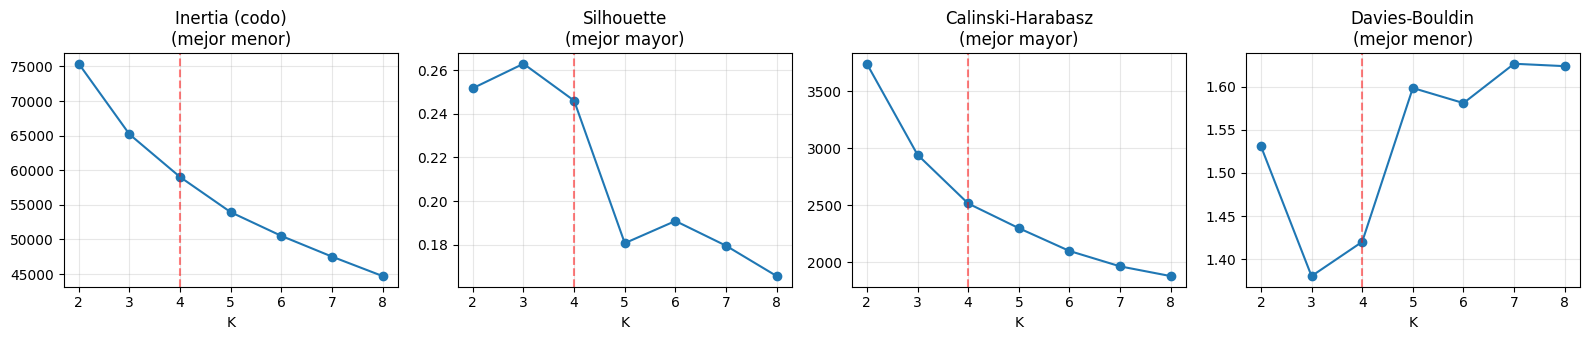

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col, titulo, direccion in zip(
    axes,
    ['inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin'],
    ['Inertia (codo)', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'],
    ['mejor menor', 'mejor mayor', 'mejor mayor', 'mejor menor'],
):
    ax.plot(metricas_k['k'], metricas_k[col], 'o-')
    ax.set_title(f'{titulo}\n({direccion})')
    ax.set_xlabel('K')
    ax.axvline(4, color='red', linestyle='--', alpha=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/01_seleccion_k.png', dpi=130, bbox_inches='tight')
plt.show()

**Decisión: K = 4.**

K = 3 tiene métricas levemente mejores en silhouette y Davies-Bouldin, pero con K = 3 el cluster de usuarios mobile queda mezclado con desktops superficiales. K = 4 separa correctamente mobile como segmento independiente, lo cual es una palanca de marketing obvia y accionable.

El criterio aquí no es solo estadístico. Cuatro segmentos con identidad clara valen más operativamente que tres segmentos algorítmicamente más limpios pero con palancas mezcladas.

## Comparación entre algoritmos

Para validar que la solución de KMeans no es un artefacto del algoritmo, comparamos con dos alternativas: clustering aglomerativo con linkage de Ward y Gaussian Mixture Model.

In [4]:
benchmark = benchmark_algorithms(X, k=4)
benchmark.round(3)

,modelo,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,4,0.246,2515.314,1.420
1,AgglomerativeWard,4,0.227,2149.117,1.409
2,GaussianMixture,4,0.184,1522.888,3.741


KMeans y Ward llegan a soluciones muy similares en silhouette y Davies-Bouldin, lo que confirma que la estructura es robusta y no producto de un algoritmo en particular. GMM produce una solución diferente porque modela los clusters como elipsoides probabilísticos, pero con peor separación geométrica.

Conservamos KMeans por simplicidad operativa: los centroides permiten asignar visitantes nuevos en producción con una operación de distancia mínima, sin necesidad de matrices de covarianza ni recomputar nada.

## Ajuste final y guardado del modelo

In [5]:
modelo = fit_final_model(X, k=4, random_state=42)
df['cluster'] = modelo.labels_
df['cluster_name'] = df['cluster'].map(CLUSTER_NAMES)
print('Tamaños de cluster:')
print(df['cluster_name'].value_counts())

Tamaños de cluster:
cluster_name
Desktop Engaged      4247
Desktop Frecuente    3819
Weekend Warriors      973
Mobile Users          957
Name: count, dtype: int64


In [6]:
joblib.dump(modelo, '../models/kmeans_k4.pkl')
df.to_pickle('../data/processed/df_clustered.pkl')
print('Modelo guardado en ../models/kmeans_k4.pkl')

Modelo guardado en ../models/kmeans_k4.pkl


## Validación de robustez

En clustering no hay etiquetas verdaderas contra qué comparar, así que la pregunta correcta no es ¿qué accuracy tiene el modelo? sino ¿qué tan estables son los clusters frente a perturbaciones?

### Bootstrap stability

Re-entrenamos KMeans 30 veces con muestras del 80% del dataset y medimos el Adjusted Rand Index entre las asignaciones de cada bootstrap y la del modelo base. ARI mide acuerdo entre dos particiones corrigiendo por azar; vale 1 cuando son idénticas, 0 cuando son tan parecidas como dos asignaciones aleatorias.

In [7]:
estabilidad = validate_stability(X, base_labels=modelo.labels_, n_bootstrap=30)
for k, v in estabilidad.items():
    print(f'  {k:15s} {v:.3f}')

  ari_medio       0.974
  ari_mediana     0.994
  ari_min         0.418
  ari_p25         0.989
  ari_p75         0.996


ARI medio cercano a 1 indica que los clusters reaparecen casi idénticos con datos distintos. No son un artefacto de la muestra completa.

### Hold-out 80/20

Entrenamos centroides con el 80% y asignamos el 20% restante usando esos centroides. Comparamos el silhouette en train vs test. Si los clusters fueran un overfit, el silhouette caería bruscamente en test.

In [8]:
holdout = validate_holdout(X, k=4, n_folds=10)
for k, v in holdout.items():
    print(f'  {k:25s} {v:.3f}')

  silhouette_train          0.243
  silhouette_test           0.243
  gap                       0.000


Gap entre train y test cercano a cero: los centroides aprendidos en una muestra generalizan a datos no vistos. No hay sobreajuste.

## Visualización en PCA

Proyectamos el espacio original a dos componentes principales para visualizar la separación entre clusters. La proyección pierde información, pero permite ver de un vistazo si los clusters ocupan regiones diferenciadas.

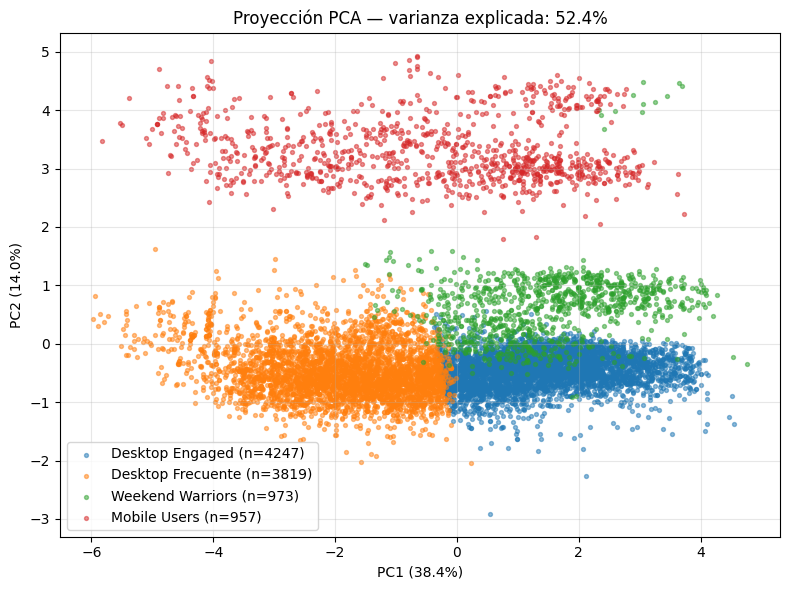

In [9]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
fig, ax = plt.subplots(figsize=(8, 6))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for c in range(4):
    mask = df['cluster'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=8, alpha=0.5, c=colores[c],
               label=f'{CLUSTER_NAMES[c]} (n={mask.sum()})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Proyección PCA — varianza explicada: {pca.explained_variance_ratio_.sum():.1%}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/02_pca_clusters.png', dpi=130, bbox_inches='tight')
plt.show()